In [1]:
%load_ext autoreload
%autoreload 2
from run_regression import *
%matplotlib inline

plt.rc('font', family='Malgun Gothic')

In [9]:
dir_ = r'C:\Users\rbs\Dropbox\101.대학원생활\1학년2학기\04_노알버트_첨단컴퓨팅세미나_목1\GCY6902'
df_1 = pd.read_parquet(f'{dir_}/data/binance_klines_1hr_260412_1.parquet')
df_1['BAS_DT'] = pd.to_datetime(df_1['Close time'], format='%Y-%m-%d').dt.strftime('%Y%m%d')
day_max_time = df_1.groupby('BAS_DT')['Close time'].max().reset_index().rename(columns={'Close time':'Max Close time'})
df_1 = df_1.merge(day_max_time, on=['BAS_DT'], how='inner')
df_1 = df_1.loc[df_1['Close time']==df_1['Max Close time'], :].copy()
df_1.drop(columns=['Max Close time'], inplace=True)

df_2 = pd.read_csv(f'{dir_}/data/multivla_input_data.csv')[['ts','DXY','GOLD','NASDAQ']]
df_2['BAS_DT'] = (pd.to_datetime(df_2['ts']).dt.strftime('%Y%m%d'))
# BAS_DT는 결합하는 데이터 시점이므로, 하루뒤에 활성화되는 정보로 판단하여 하루 추가 처리하다가 다시 원복 
# + pd.Timedelta(days=1)).dt.strftime('%Y%m%d')

df = df_1.merge(df_2[['BAS_DT','DXY','GOLD','NASDAQ']], on='BAS_DT', how='left')
var_list = ['Open', 'High', 'Low', 'Close', 'Volume', 'DXY', 'GOLD', 'NASDAQ']

In [13]:
df.to_parquet(f'{dir_}/data/df_260503.parquet', index=False)

In [14]:
%reload_ext autoreload
target = "Close" 
config_dict = {'d_model':8,
    'hidden_dim': 64,#128
    'lstm_hidden': 64,#128
    'n_heads': 4,
    'dropout': 0.2,

    'past_vars': len(var_list),
    'known_vars':  1,   # 예: time index, month, quarter 등
    'static_vars':  1,
    'output_mode': "regression"  # "regression" | "binary" | "multiclass"
}
for SEQ in [60]: # 시퀀스 길이 실험
    outdir = "./output/" + datetime.now().strftime('%y%m%d%H%M')+f"_1_SEQ{str(SEQ).zfill(2)}/"
    os.mkdir(outdir)

    fit_and_out(
        df,
        target,
        outdir,
        config_dict,
        var_list=var_list,
        grp_cd="Symbol",
        epochs=50,
        patience=10,
        threshold=0.05,
        trk_start_dt='20240101',
        seq_length=SEQ,
        dt_cut='20251231',
        tgt_gap=3,
        seed=42,
        train_yn=1
    )

====target : 4 Close=====
train: 20240101~20251101 자료 추출 중 : 201814
validation set : 20250929~20251231 자료 추출 중 : 39115
test set : 20260109~20260412 자료 추출 중 : 40735
=======1. TFT 모델 학습중=======


KeyboardInterrupt: 

====target : 4 Close=====
train: 201707~202312 자료 추출 중 : 21138
validation set : 202304~202412 자료 추출 중 : 5691
test set : 202404~202512 자료 추출 중 : 5691
=======1. TFT 모델 학습중=======
***[TFT Epoch:001] train_loss=0.134189 | val_loss=0.165895 | test_loss=0.268251 | lr=4.88e-04***
 -> saved best to ./output/2605011632_SEQ06/Close_tft_test_260501.pt
***[TFT Epoch:002] train_loss=0.130477 | val_loss=0.152586 | test_loss=0.251780 | lr=4.53e-04***
 -> saved best to ./output/2605011632_SEQ06/Close_tft_test_260501.pt
***[TFT Epoch:003] train_loss=0.127092 | val_loss=0.141087 | test_loss=0.235992 | lr=3.99e-04***
 -> saved best to ./output/2605011632_SEQ06/Close_tft_test_260501.pt
***[TFT Epoch:004] train_loss=0.126469 | val_loss=0.151105 | test_loss=0.249516 | lr=3.31e-04***
***[TFT Epoch:005] train_loss=0.120976 | val_loss=0.140825 | test_loss=0.235104 | lr=2.55e-04***
 -> saved best to ./output/2605011632_SEQ06/Close_tft_test_260501.pt
***[TFT Epoch:006] train_loss=0.117422 | val_loss=0.143464 | t

c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\260501_2_qloss_백업\run_regression.py:492: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(3) Hit-rate(상/하위 10개)==========


c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\260501_2_qloss_백업\run_regression.py:534: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\260501_2_qloss_백업\run_regression.py:542: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


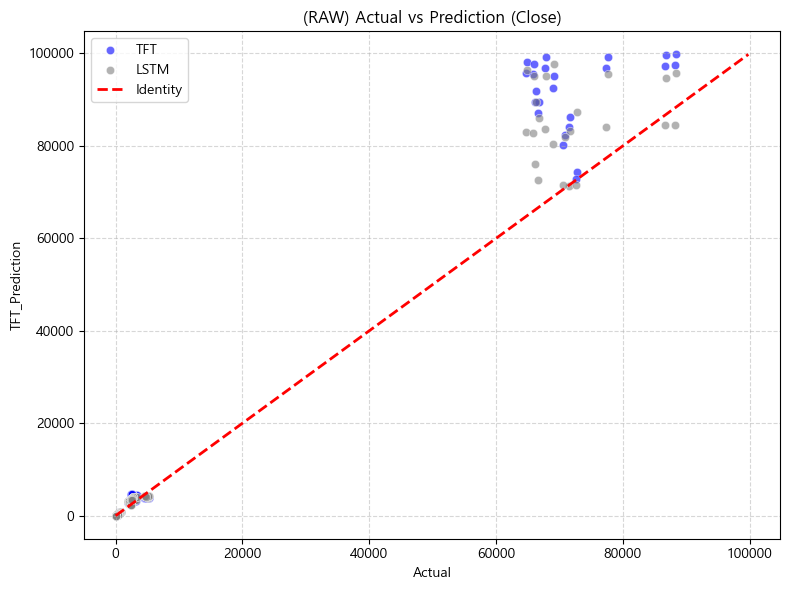

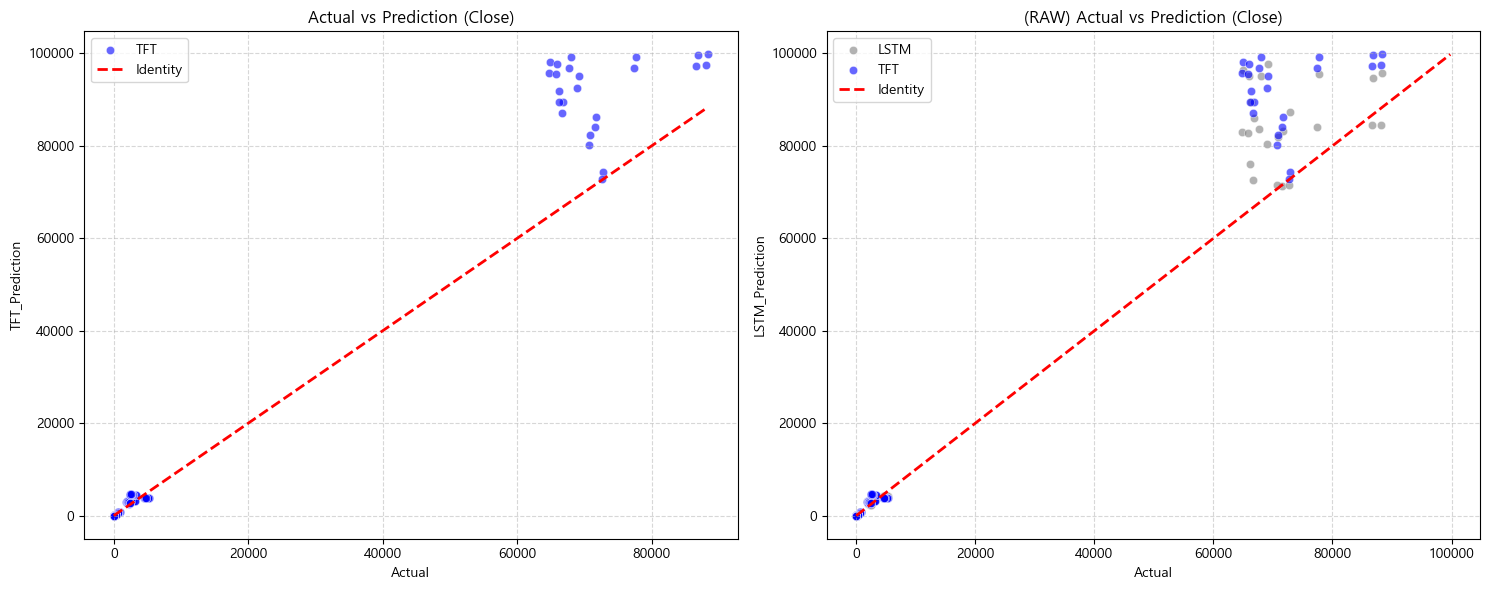

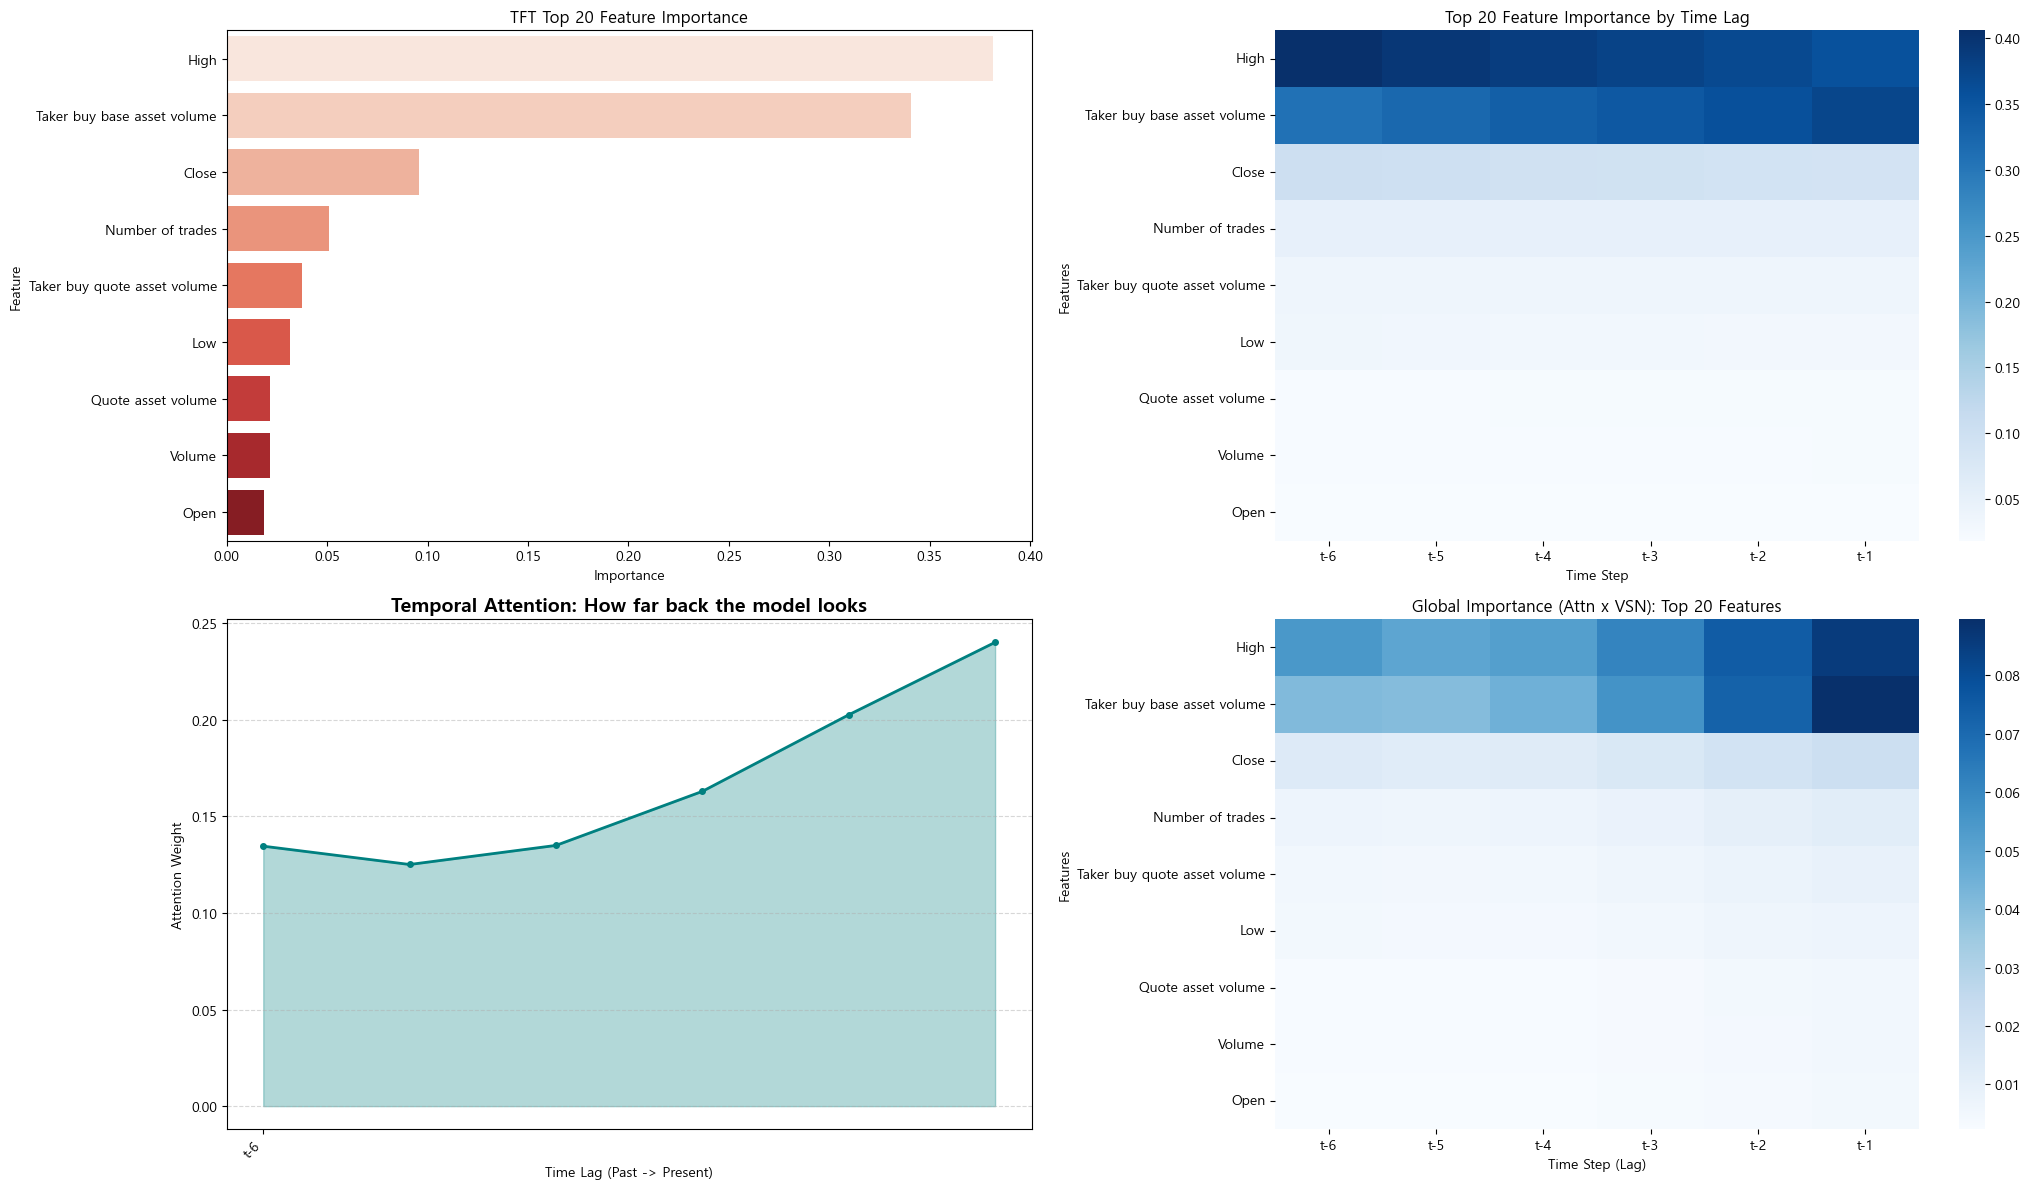

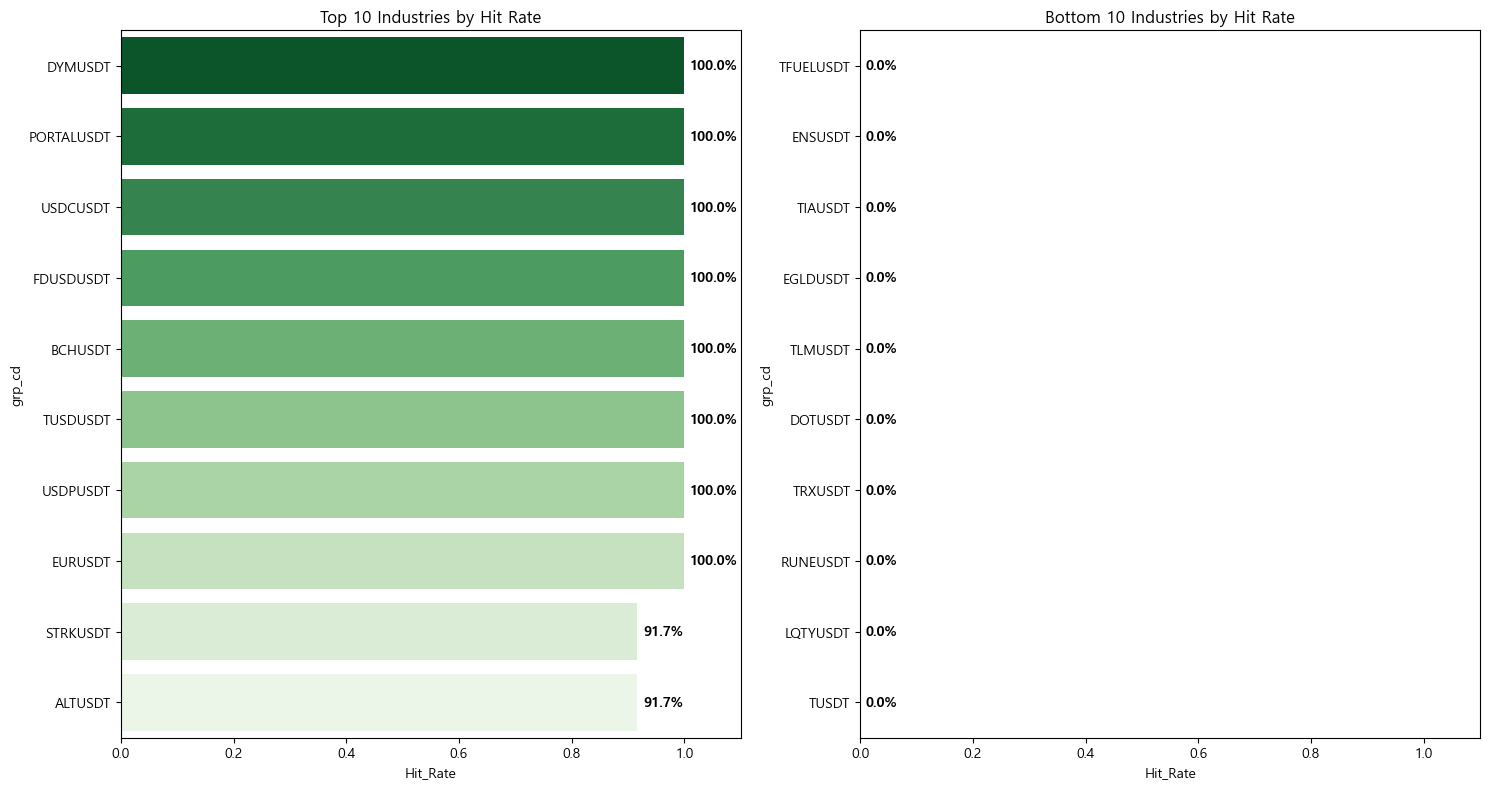

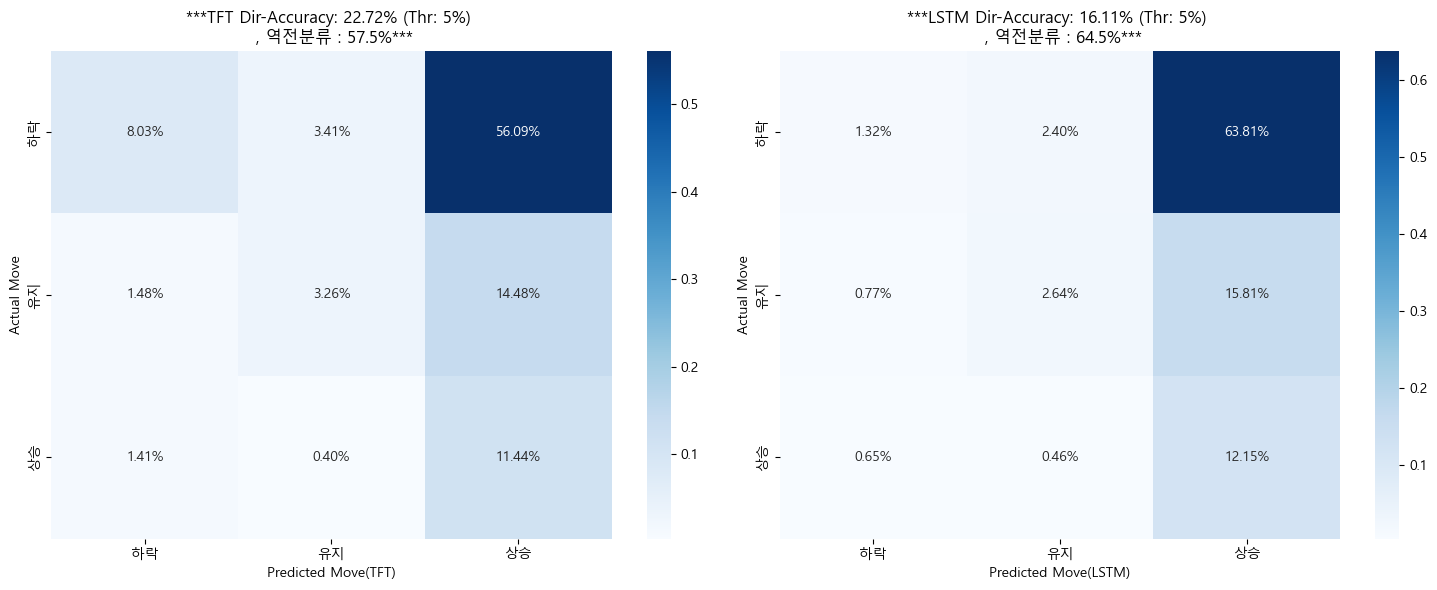

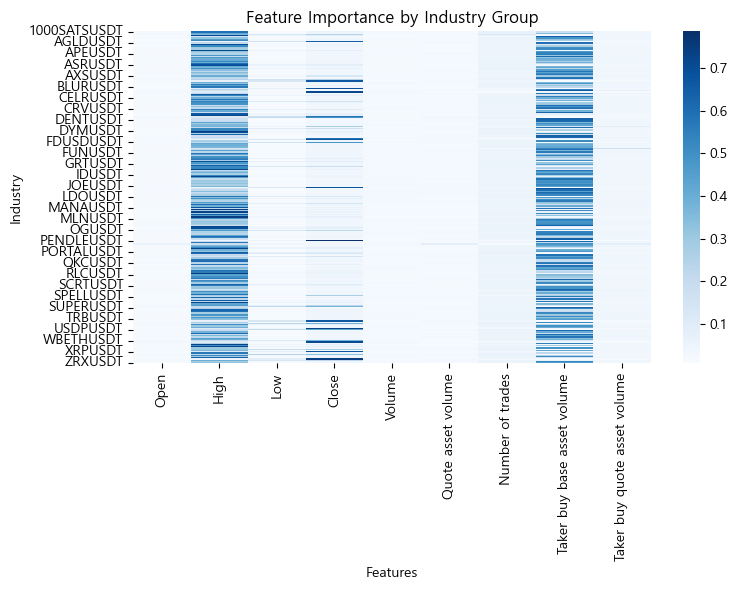

In [4]:
for SEQ in [6]: # 시퀀스 길이 실험
    outdir = "./output/" + datetime.now().strftime('%y%m%d%H%M')+f"_SEQ{str(SEQ).zfill(2)}/"
    os.mkdir(outdir)

    fit_and_out(
        df,
        target,
        outdir,
        config_dict,
        var_list=var_list,
        grp_cd="Symbol",
        epochs=50,
        patience=20,
        threshold=0.05,
        trk_start_ym=201707,
        seq_length=SEQ,
        ym_cut=202412,
        tgt_gap=3,
        seed=42,
        train_yn=1
    )

====target : 4 Close=====
train: 201707~202312 자료 추출 중 : 21138
validation set : 202304~202412 자료 추출 중 : 5691
test set : 202404~202512 자료 추출 중 : 5691
=======1. TFT 모델 학습중=======
***[TFT Epoch:001] train_loss=0.128565 | val_loss=0.162253 | test_loss=0.244626 | lr=4.88e-04***
 -> saved best to ./output/2605011935_SEQ06/Close_tft_test_260501.pt
***[TFT Epoch:002] train_loss=0.123117 | val_loss=0.133656 | test_loss=0.196514 | lr=4.53e-04***
 -> saved best to ./output/2605011935_SEQ06/Close_tft_test_260501.pt
***[TFT Epoch:003] train_loss=0.114383 | val_loss=0.132509 | test_loss=0.203459 | lr=3.99e-04***
 -> saved best to ./output/2605011935_SEQ06/Close_tft_test_260501.pt
***[TFT Epoch:004] train_loss=0.109028 | val_loss=0.128000 | test_loss=0.200440 | lr=3.31e-04***
 -> saved best to ./output/2605011935_SEQ06/Close_tft_test_260501.pt
***[TFT Epoch:005] train_loss=0.107067 | val_loss=0.136199 | test_loss=0.201512 | lr=2.55e-04***
***[TFT Epoch:006] train_loss=0.104202 | val_loss=0.123283 | t

c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\260501_2_qloss_백업\run_regression.py:492: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(3) Hit-rate(상/하위 10개)==========


c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\260501_2_qloss_백업\run_regression.py:534: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\260501_2_qloss_백업\run_regression.py:542: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


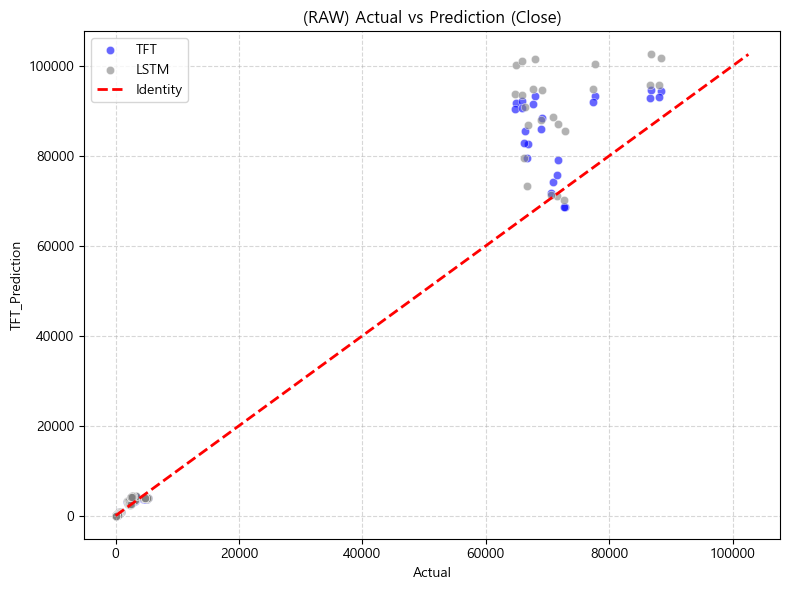

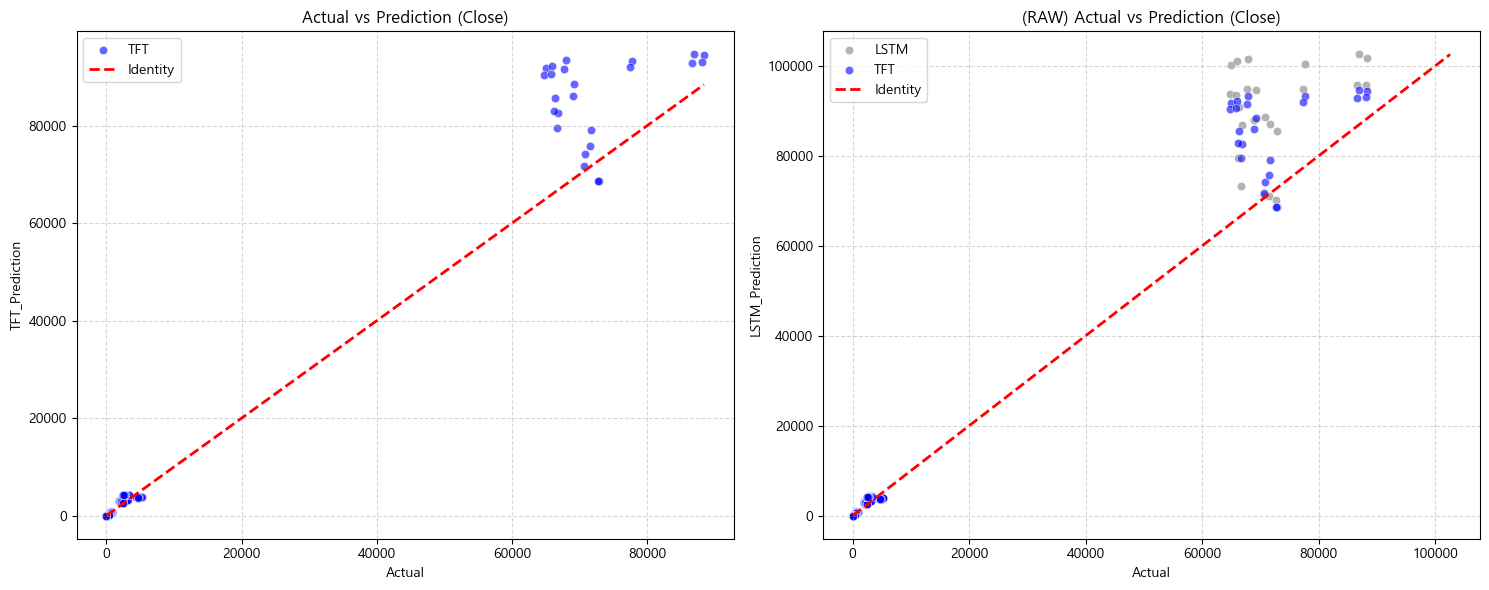

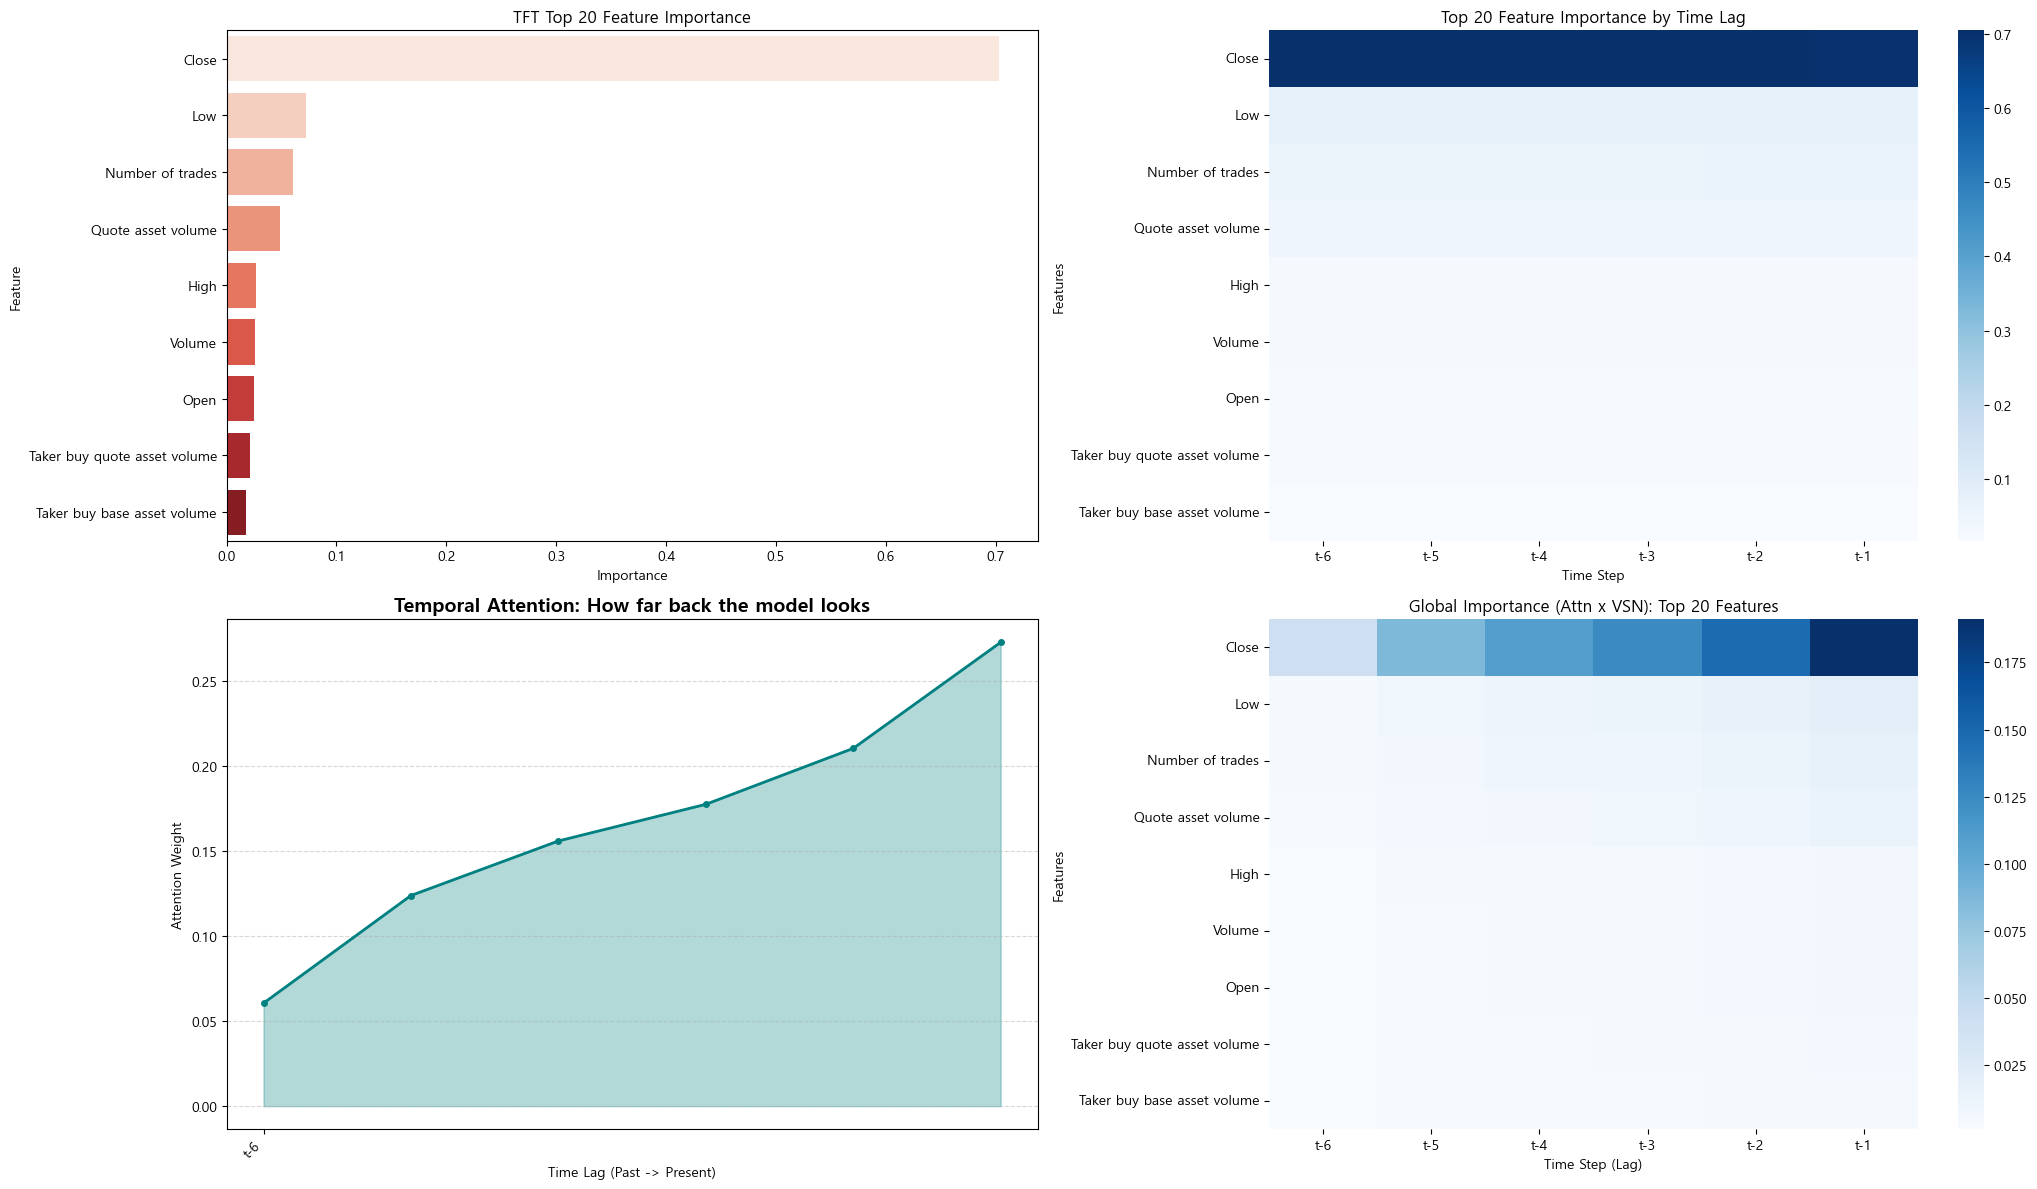

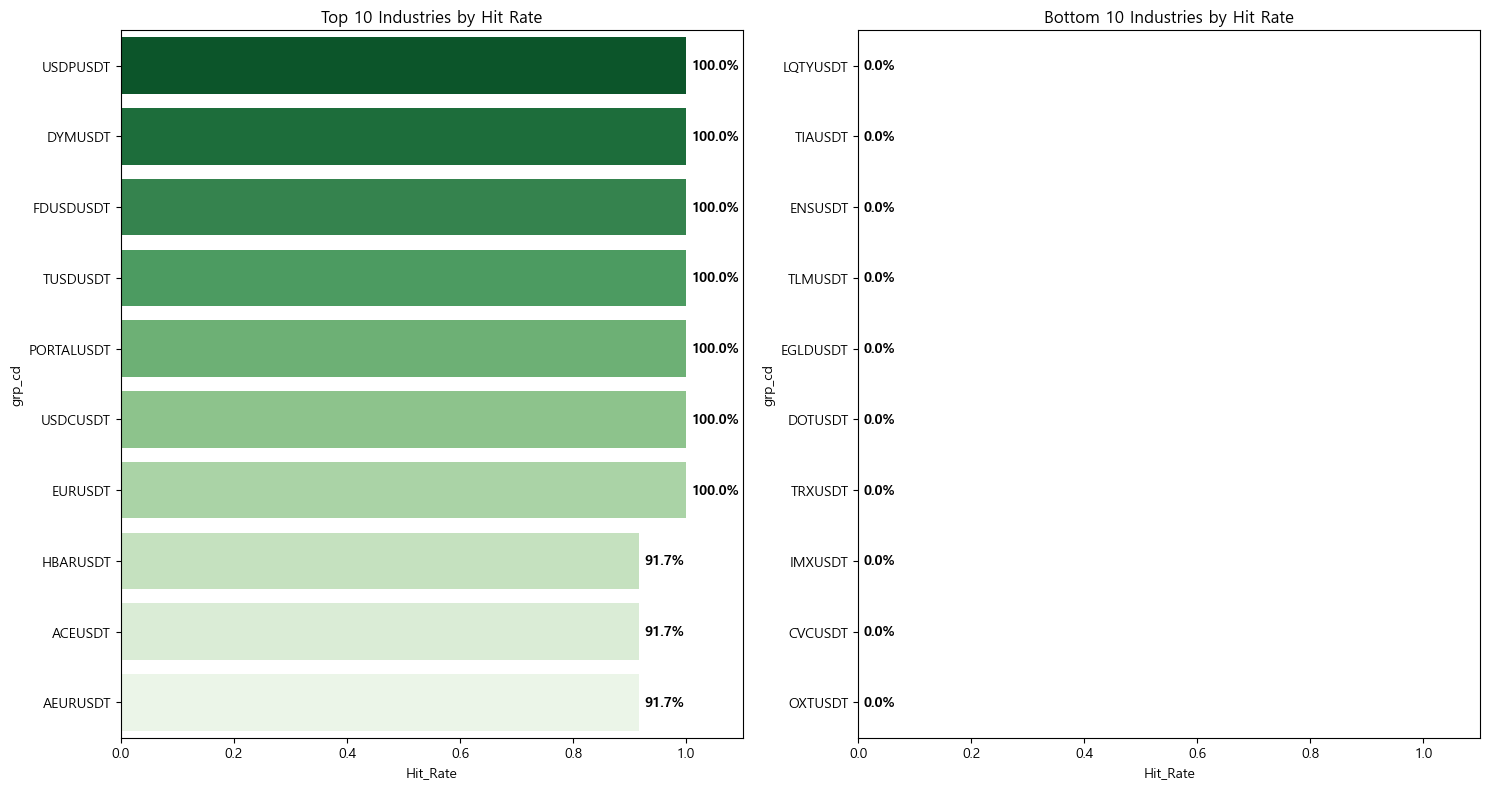

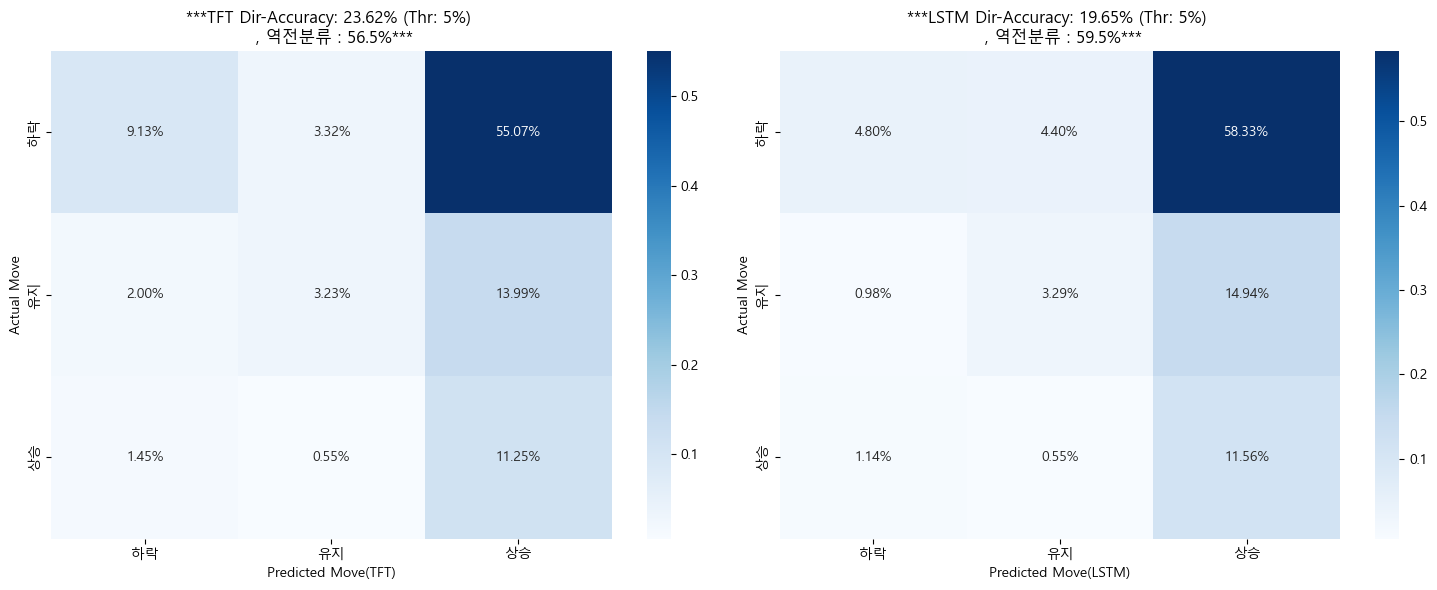

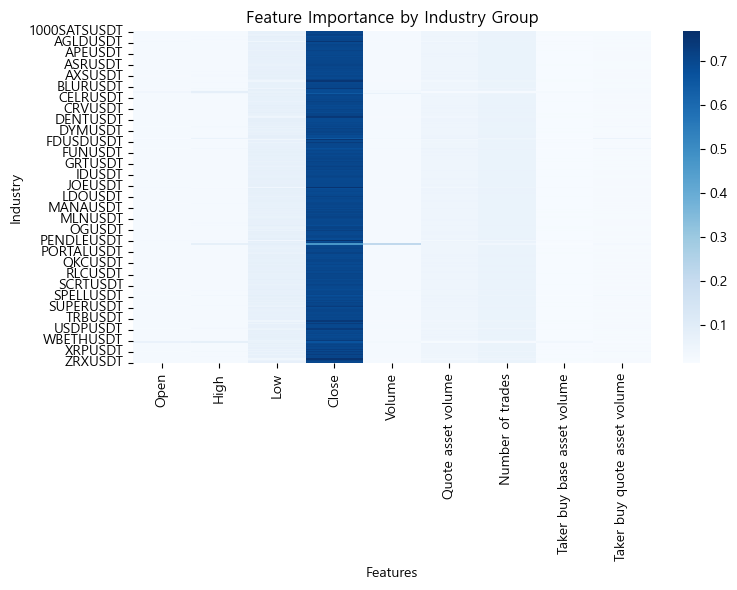

In [5]:
target = "Close" 
config_dict = {'d_model':32,
    'hidden_dim': 64,#128
    'lstm_hidden': 64,#128
    'n_heads': 4,
    'dropout': 0.2,

    'past_vars': len(var_list),
    'known_vars':  1,   # 예: time index, month, quarter 등
    'static_vars':  1,
    'output_mode': "regression"  # "regression" | "binary" | "multiclass"
}
for SEQ in [6]: # 시퀀스 길이 실험
    outdir = "./output/" + datetime.now().strftime('%y%m%d%H%M')+f"_SEQ{str(SEQ).zfill(2)}/"
    os.mkdir(outdir)

    fit_and_out(
        df,
        target,
        outdir,
        config_dict,
        var_list=var_list,
        grp_cd="Symbol",
        epochs=50,
        patience=10,
        threshold=0.05,
        trk_start_ym=201707,
        seq_length=SEQ,
        ym_cut=202412,
        tgt_gap=3,
        seed=42,
        train_yn=1
    )

====target : 4 Close=====
train: 201707~202312 자료 추출 중 : 21138
validation set : 202304~202412 자료 추출 중 : 5691
test set : 202404~202512 자료 추출 중 : 5691
=======1. TFT 모델 학습중=======
***[TFT Epoch:001] train_loss=0.150184 | val_loss=0.159392 | test_loss=0.238481 | lr=9.78e-05***
 -> saved best to ./output/2605012029_SEQ06/Close_tft_test_260501.pt
***[TFT Epoch:002] train_loss=0.140653 | val_loss=0.168906 | test_loss=0.260969 | lr=9.14e-05***
***[TFT Epoch:003] train_loss=0.131414 | val_loss=0.143985 | test_loss=0.228797 | lr=8.15e-05***
 -> saved best to ./output/2605012029_SEQ06/Close_tft_test_260501.pt
***[TFT Epoch:004] train_loss=0.127434 | val_loss=0.157166 | test_loss=0.248889 | lr=6.89e-05***
***[TFT Epoch:005] train_loss=0.125580 | val_loss=0.147051 | test_loss=0.235042 | lr=5.50e-05***
***[TFT Epoch:006] train_loss=0.124349 | val_loss=0.141180 | test_loss=0.224992 | lr=4.11e-05***
 -> saved best to ./output/2605012029_SEQ06/Close_tft_test_260501.pt
***[TFT Epoch:007] train_loss=0.12

c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\260501_2_qloss_백업\run_regression.py:492: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(3) Hit-rate(상/하위 10개)==========


c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\260501_2_qloss_백업\run_regression.py:534: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\260501_2_qloss_백업\run_regression.py:542: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


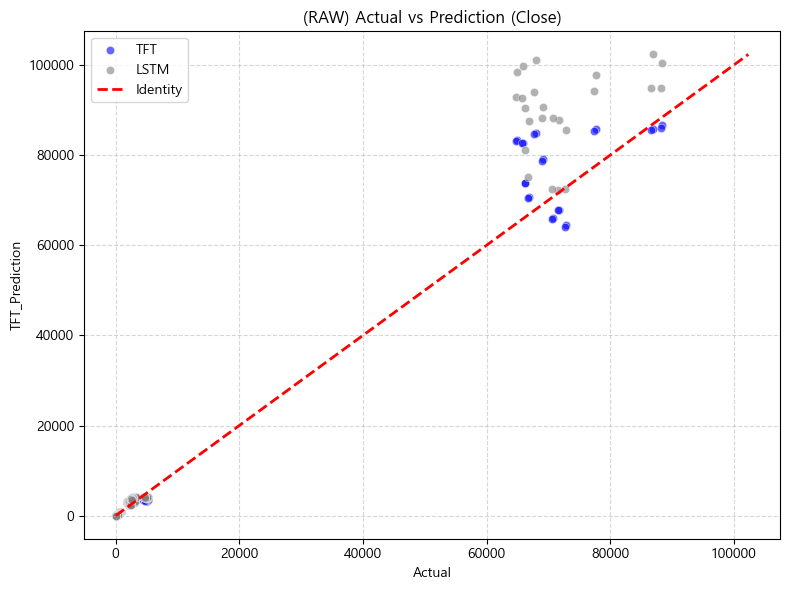

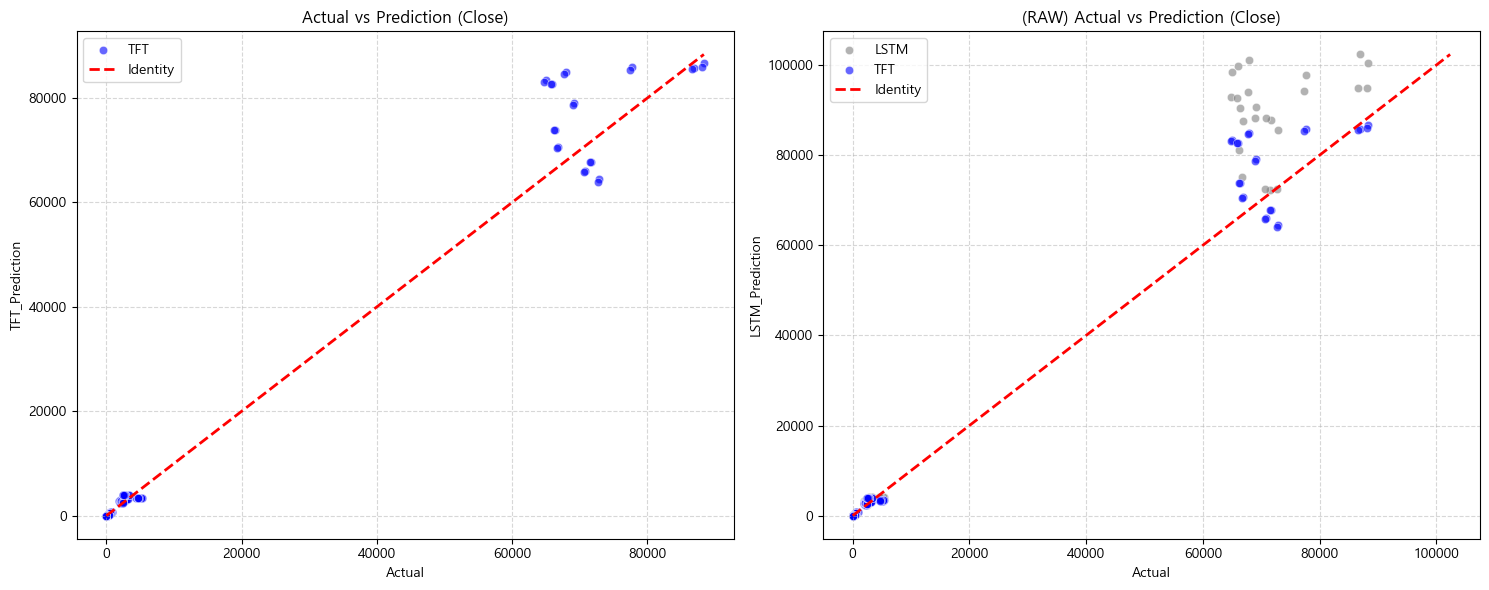

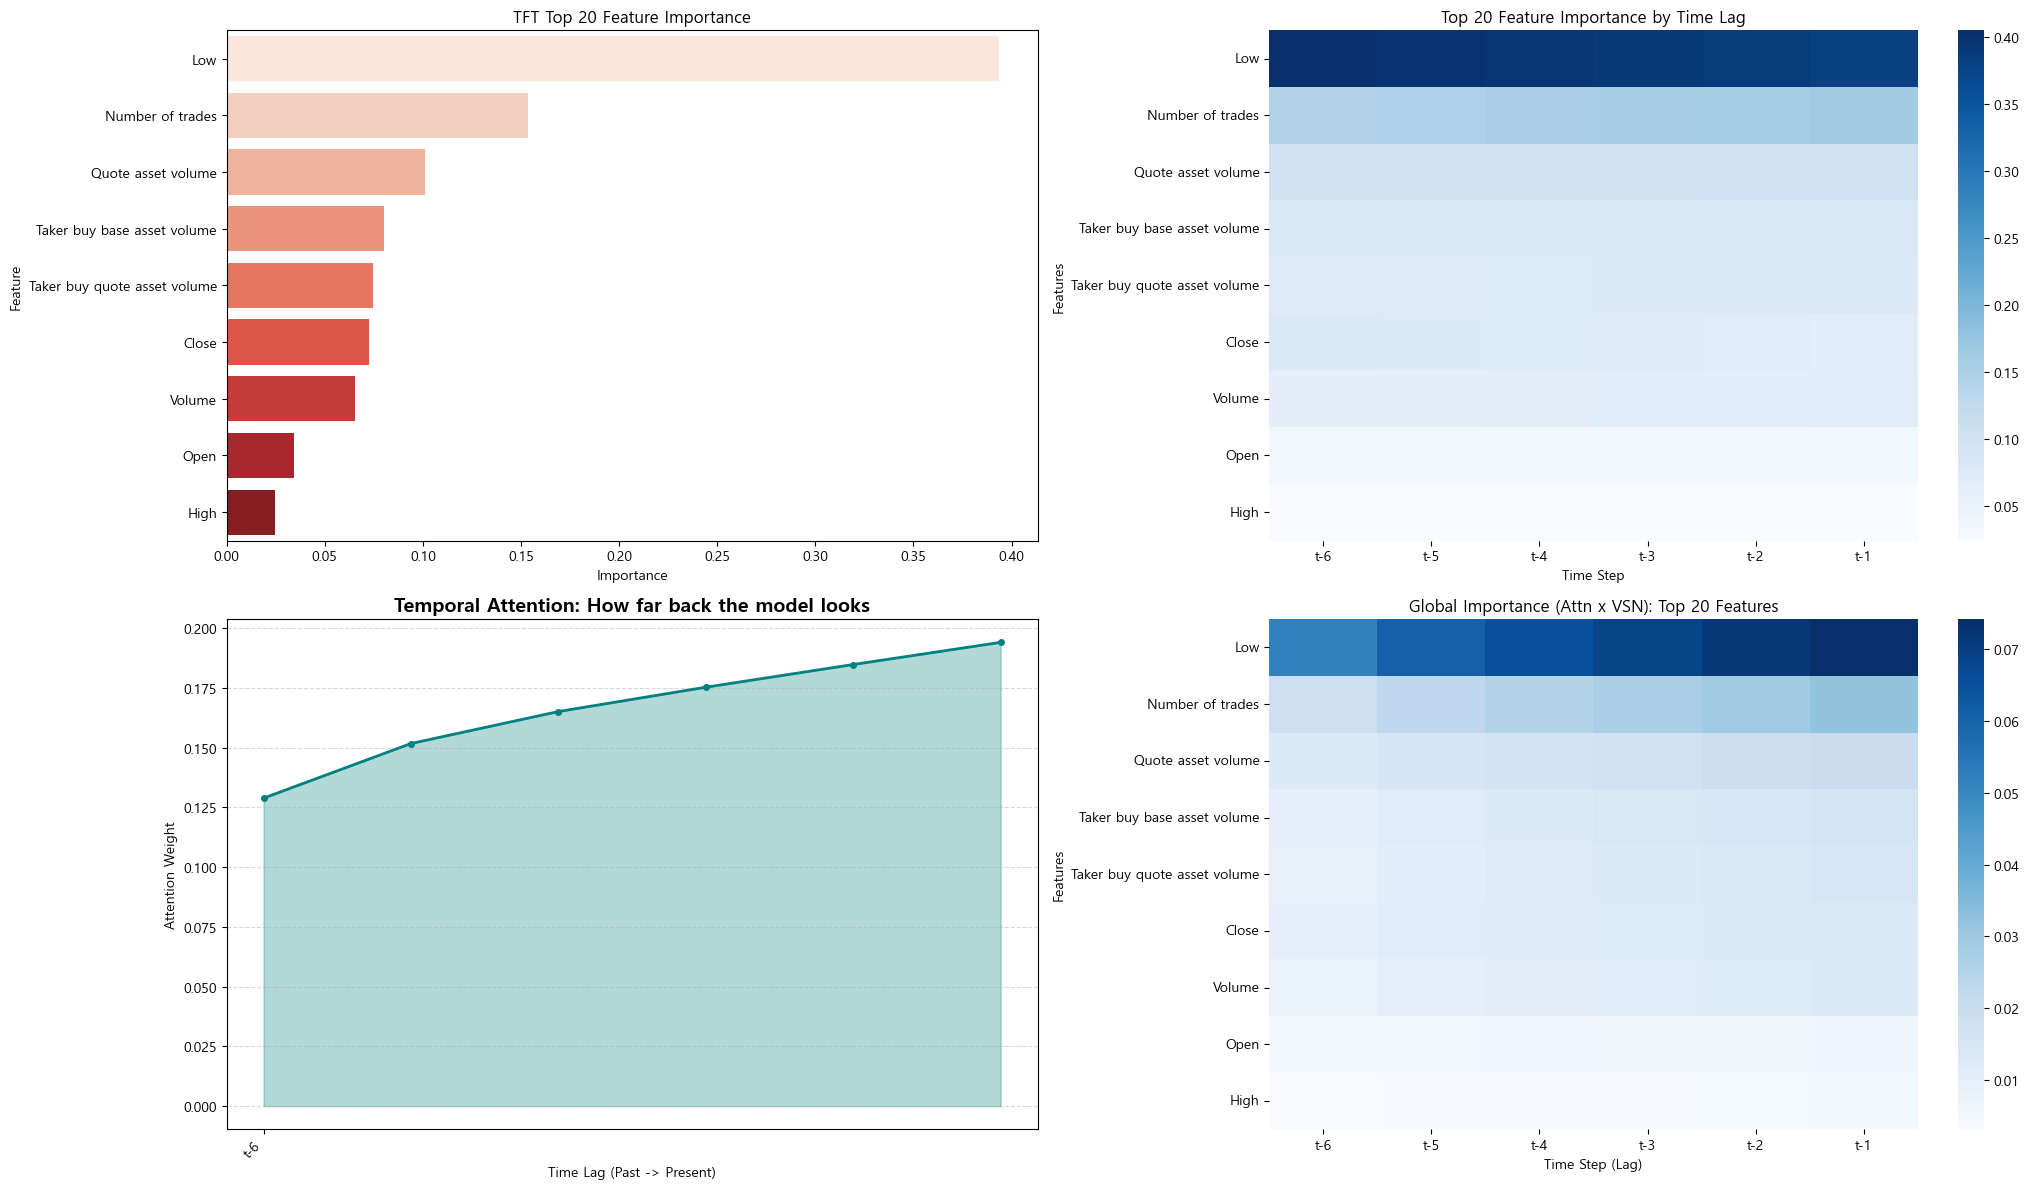

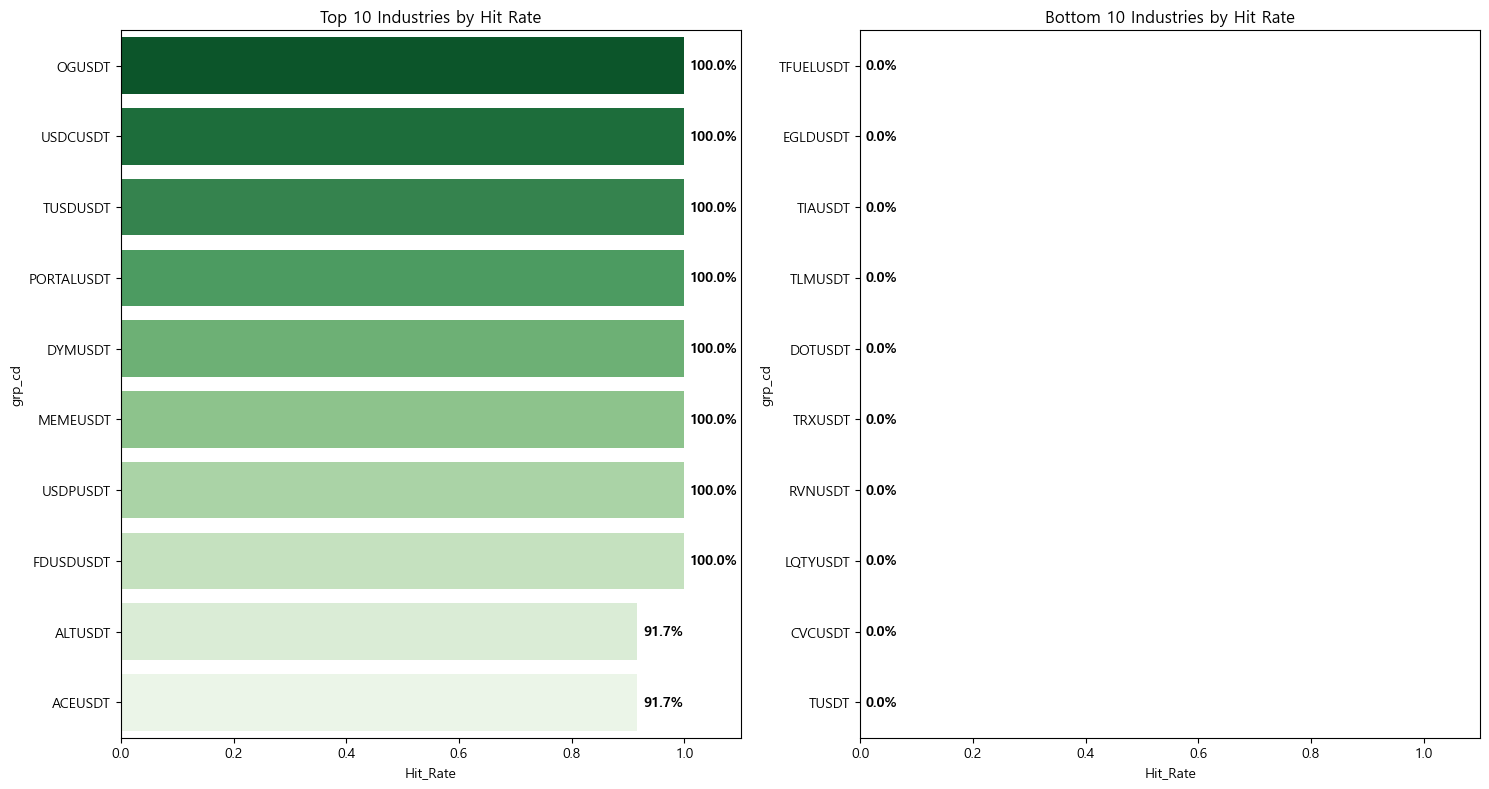

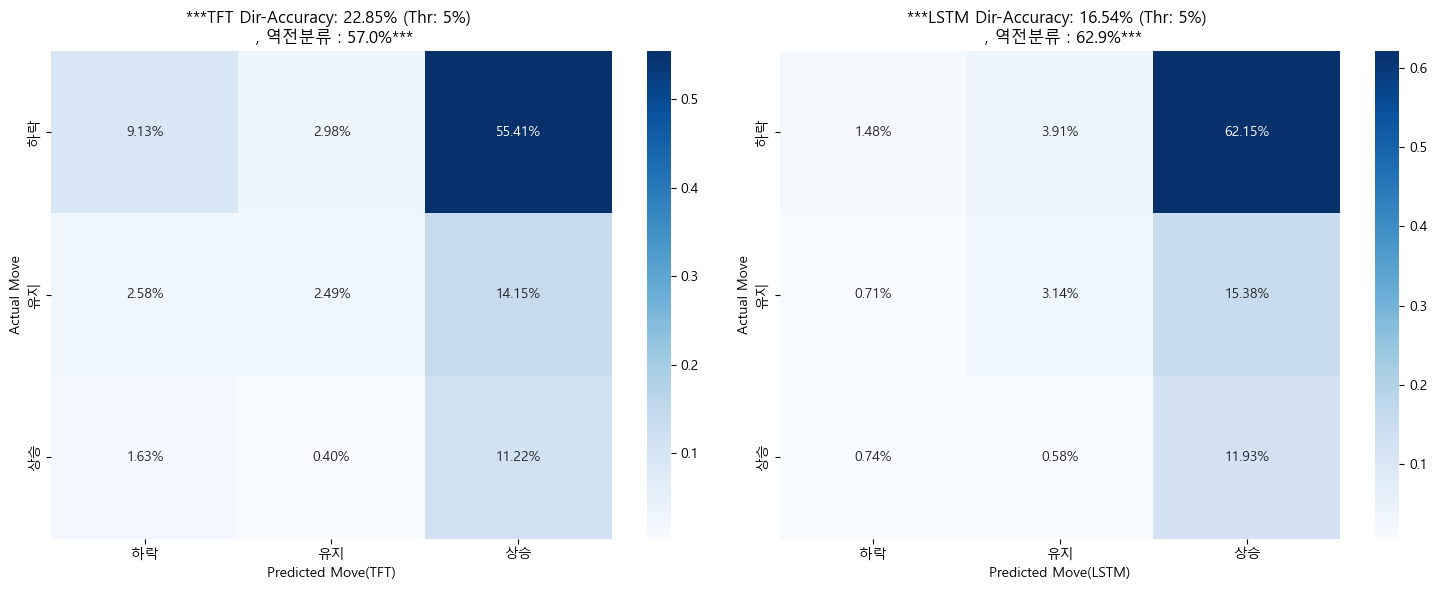

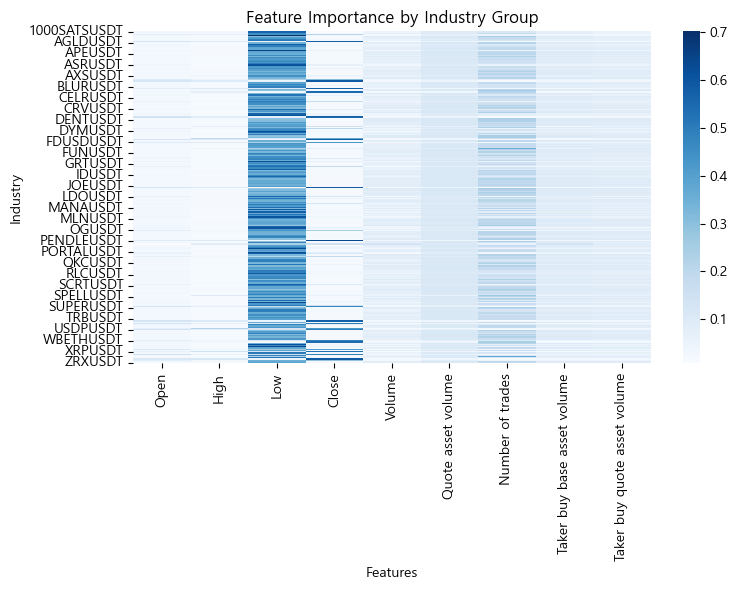

In [6]:
for SEQ in [6]: # 시퀀스 길이 실험
    outdir = "./output/" + datetime.now().strftime('%y%m%d%H%M')+f"_SEQ{str(SEQ).zfill(2)}/"
    os.mkdir(outdir)

    fit_and_out(
        df,
        target,
        outdir,
        config_dict,
        var_list=var_list,
        grp_cd="Symbol",
        lr = 1e-4,
        epochs=50,
        patience=20,
        threshold=0.05,
        trk_start_ym=201707,
        seq_length=SEQ,
        ym_cut=202412,
        tgt_gap=3,
        seed=42,
        train_yn=1
    )